In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from astropy.io import fits
from copy import deepcopy
import sunpy
import sunpy.map
from sunpy.coordinates import propagate_with_solar_surface
from sun_blinker import SunBlinker
import astropy
from astropy import units as u
from astropy.coordinates import SkyCoord
from scipy.io import readsav
from glob import glob 
import os
from tqdm.notebook import tqdm
from IPython.display import HTML
from skimage.registration import phase_cross_correlation
from scipy import ndimage

In [2]:
with fits.open("../../data/pid_1_123_aux/CHASE/RSM20221024T191230_0022_HA.fits") as hdul:
    hdul.info()
    chase_halpha_data = hdul[1].data[:]
    chase_header = deepcopy(hdul[1].header)

Filename: ../../data/pid_1_123_aux/CHASE/RSM20221024T191230_0022_HA.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (2304, 2313)   int16   
  1  COMPRESSED_IMAGE    1 CompImageHDU     49   (2304, 2313, 118)   int16   


In [3]:
chase_halpha_data.shape

(118, 2313, 2304)

In [4]:
chase_header 

XTENSION= 'IMAGE   '                                                            
BITPIX  =                   16 / data type of original image                    
NAXIS   =                    3 / Number of data axes                            
NAXIS1  =                 2304 / Length of data axis 1 (slit dimension)         
NAXIS2  =                 2313 / Length of data axis 2 (scanning steps)         
NAXIS3  =                  118 / Length of data axis 3 (wavelength dimension)   
PCOUNT  =                    0                                                  
GCOUNT  =                    1                                                  
TELESCOP= 'CHASE-HIS'          / Telescop Name                                  
BIN     =                    2 / Binning mode                                   
DATE_OBS= '2022-10-24T19:12:30' / Observation time                              
CRPIX1  =    1169.993247458284 / X coordinate of solar center in pixel          
CUNIT1  = 'arcsec  '        

In [5]:
chase_subregion_dict = readsav("../../data/pid_1_123_aux/CHASE/sub_region.sav", verbose=True)

--------------------------------------------------
Date: Mon Mar 18 18:54:00 2024
User: niyw
Host: solarmanage
--------------------------------------------------
Format: 12
Architecture: x86_64
Operating System: linux
IDL Version: 8.8.0
--------------------------------------------------
Successfully read 5 records of which:
 - 2 are of type VARIABLE
 - 1 are of type VERSION
 - 1 are of type TIMESTAMP
--------------------------------------------------
Available variables:
 - xrs [<class 'numpy.ndarray'>]
 - yrs [<class 'numpy.ndarray'>]
--------------------------------------------------


In [6]:
chase_subregion_dict["xrs"], chase_subregion_dict["yrs"]

(array([-900,    0], dtype='>i2'), array([-200,  700], dtype='>i2'))

(-0.5, 2303.5)

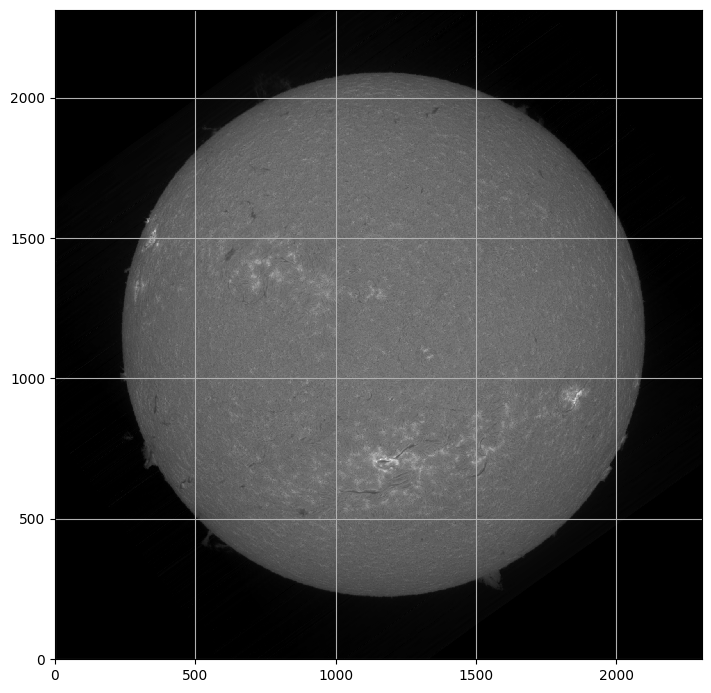

In [7]:
plt.close("all")
# %matplotlib ipympl 

fig, ax = plt.subplots(figsize=(7,7), layout="constrained")
ax.imshow(
    chase_halpha_data[70,:,:],
    origin="lower",
    cmap="grey",
    interpolation="none"

)

ax.grid("on")

ax.set_xlim()

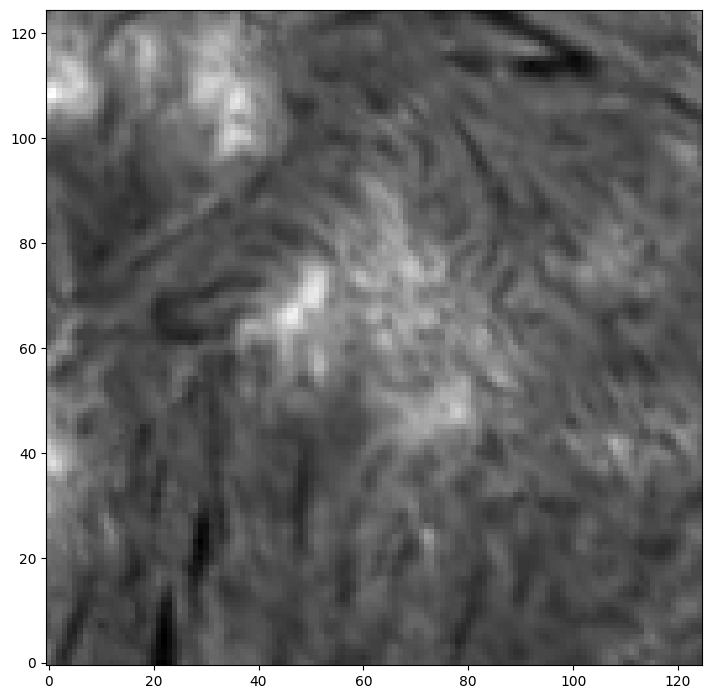

In [8]:
chase_halpha_data_cutout = chase_halpha_data[:,1300:1425, 725:850]

fig, ax = plt.subplots(figsize=(7,7), layout="constrained")
ax.imshow(
    chase_halpha_data_cutout[70,:,:],
    origin="lower",
    cmap="grey",
    interpolation="none"
)

In [9]:
def find_line_width(wvl,spec, line_core_slice = np.s_[62:77], line_slice = np.s_[50:87]):
    if spec[-1] < 100:
        return np.nan
    else:
        line_core_fit_param = np.polyfit(wvl[line_core_slice], spec[line_core_slice], 2)
        line_core_fit = np.poly1d(line_core_fit_param)

        line_cen = - line_core_fit_param[1] / (2 * line_core_fit_param[0])
        line_min = line_core_fit_param[2] - line_core_fit_param[1]**2/(4*line_core_fit_param[0])
        
        line_wing_int = (np.interp(line_cen - 1., wvl, spec) + \
                        np.interp(line_cen + 1., wvl, spec)) / 2
        
        half_int = (line_min + line_wing_int) / 2

        line_width =  np.interp(half_int, spec[line_core_slice.stop:line_slice.stop], wvl[line_core_slice.stop:line_slice.stop])- \
                        np.interp(half_int, np.flip(spec[line_slice.start:line_core_slice.start]), np.flip(wvl[line_slice.start:line_core_slice.start]))
        return line_width

In [10]:
def extract_line_width_from_map(chase_halpha_data, chase_header,
    filename=None,
    line_slice = np.s_[50:87], line_core_slice = np.s_[62:77],
    ):
    chase_wavelength = (np.arange(chase_header["NAXIS3"]) + 1 - (chase_header["CRPIX3"] + 1))*chase_header["CDELT3"] + chase_header["CRVAL3"]

    chase_halpha_data_flat = chase_halpha_data.reshape(chase_halpha_data.shape[0], -1)
    chase_halpha_line_width = np.zeros(chase_halpha_data_flat.shape[1])
    for ii in range(chase_halpha_data_flat.shape[1]):
        chase_halpha_line_width[ii] = find_line_width(chase_wavelength, chase_halpha_data_flat[:,ii])
    chase_halpha_line_width = chase_halpha_line_width.reshape(chase_halpha_data.shape[1:])

    if filename is not None:
        np.save(filename, chase_halpha_line_width)
    else:
        return chase_halpha_line_width

In [11]:
chase_halpha_line_width_test = extract_line_width_from_map(chase_halpha_data_cutout, chase_header,
    line_slice = np.s_[50:87], line_core_slice = np.s_[62:77])

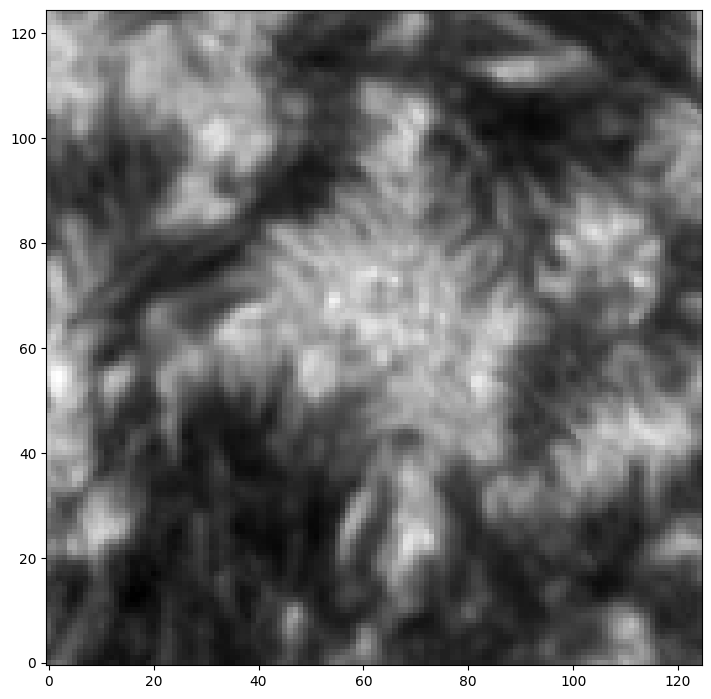

In [12]:


fig, ax = plt.subplots(figsize=(7,7), layout="constrained")
ax.imshow(
    chase_halpha_line_width_test,
    origin="lower",
    cmap="grey",
    interpolation="none"
)

In [13]:
chase_files = sorted(glob("../../data/pid_1_123_aux/CHASE/RSM*.fits"))

In [14]:
# for ii, filename in enumerate(tqdm(chase_files)):
#     with fits.open(filename) as hdul:
#         # hdul.info()
#         chase_halpha_data = hdul[1].data[:]
#         chase_header = deepcopy(hdul[1].header)
    
#     basename = os.path.basename(filename)
#     basename_to_save = basename.split(".")[0] + "_line_width.npy"
#     filename_save = os.path.join("../../data/pid_1_123_aux/CHASE/chase_line_width_npy/", basename_to_save)
    
#     extract_line_width_from_map(chase_halpha_data[:,1300:1425, 725:850], chase_header, filename_save,
#     line_slice = np.s_[50:87], line_core_slice = np.s_[62:77],
#     )

In [15]:
chase_line_width_files = sorted(glob("../../data/pid_1_123_aux/CHASE/chase_line_width_npy/*.npy"))

chase_line_width_cube = np.zeros((125, 125, len(chase_line_width_files)))

for ii, filename in enumerate(tqdm(chase_line_width_files)):
    chase_line_width_cube[:,:,ii] = np.load(filename)

  0%|          | 0/11 [00:00<?, ?it/s]

In [23]:
def animate_line_width(chase_line_width_cube, fps=2):
    fig, ax = plt.subplots(figsize=(7,7),)
    im = ax.imshow(chase_line_width_cube[:,:,0], origin="lower", cmap="grey", interpolation="none")
    
    def update(ii):
        im.set_data(chase_line_width_cube[:,:,ii])
        return im,
    
    anim = animation.FuncAnimation(fig, update,
           frames=chase_line_width_cube.shape[2], interval=1000/fps, blit=False)
    
    plt.close("all")
    return anim

    

In [24]:
chase_line_width_anim = animate_line_width(chase_line_width_cube)

HTML(chase_line_width_anim.to_jshtml())

In [18]:
chase_line_core_cube = np.zeros((2313, 2304, len(chase_files)))

for ii, filename in enumerate(chase_files):
    chase_line_core_cube[:,:,ii] = fits.getdata(filename, ext=1)[70,:,:]

In [19]:
chase_bw_cube = np.zeros((2313, 2304, len(chase_files)))

for ii, filename in enumerate(chase_files):
    chase_bw_cube[:,:,ii] = fits.getdata(filename, ext=1)[70-18,:,:]

In [31]:
shiftx, shifty = np.zeros((2, len(chase_files)))

for ii in tqdm(range(len(chase_files) - 2, -1, -1)):
    corr_shift, _, _ = phase_cross_correlation(chase_line_core_cube[:,:,ii+1], chase_line_core_cube[:,:,ii],
    upsample_factor=10, reference_mask=np.isfinite(chase_line_core_cube[:,:,ii+1]),
    moving_mask=np.isfinite(chase_line_core_cube[:,:,ii]))

    shiftx[ii] = corr_shift[1] + shiftx[ii+1]
    shifty[ii] = corr_shift[0] + shifty[ii+1]




  0%|          | 0/10 [00:00<?, ?it/s]

In [32]:
chase_line_width_cube_shifted = np.zeros((125, 125, len(chase_files)))

for ii in tqdm(range(len(chase_files))):
    chase_line_width_cube_shifted[:,:,ii] = ndimage.shift(chase_line_width_cube[:,:,ii], (shifty[ii], shiftx[ii]))

  0%|          | 0/11 [00:00<?, ?it/s]

In [33]:
chase_line_width_shift_anim = animate_line_width(chase_line_width_cube_shifted[:105,:105,:])

HTML(chase_line_width_shift_anim.to_jshtml())

In [34]:
chase_bw_cube_shifted = np.zeros((125, 125, len(chase_files)))

for ii in tqdm(range(len(chase_files))):
    chase_bw_cube_shifted[:,:,ii] = ndimage.shift(chase_bw_cube[1300:1425,725:850,ii], (shifty[ii], shiftx[ii]))

  0%|          | 0/11 [00:00<?, ?it/s]

In [35]:
chase_bw_shifted_anim = animate_line_width(chase_bw_cube_shifted[:105,:105,:])

HTML(chase_bw_shifted_anim.to_jshtml())

In [36]:
chase_line_core_cube_shifted = np.zeros((125, 125, len(chase_files)))

for ii in tqdm(range(len(chase_files))):
    chase_line_core_cube_shifted[:,:,ii] = ndimage.shift(chase_line_core_cube[1300:1425,725:850,ii], (shifty[ii], shiftx[ii]))

  0%|          | 0/11 [00:00<?, ?it/s]

In [37]:
chase_line_core_shifted_anim = animate_line_width(chase_line_core_cube_shifted[:105,:105,:])

HTML(chase_line_core_shifted_anim.to_jshtml())

In [39]:
chase_fits_header = sunpy.map.make_fitswcs_header(chase_halpha_data[0,:,:].shape,
                                                  SkyCoord(chase_header["CRVAL1"]*u.arcsec,chase_header["CRVAL2"]*u.arcsec,
                                                           obstime=chase_header["DATE_OBS"],observer="Earth",frame="helioprojective",
                                                           rsun=696000000.0*u.m),
                                                  reference_pixel=[chase_header["CRPIX1"],chase_header["CRPIX2"]]*u.pix,
                                                  scale=u.Quantity([chase_header["CDELT1"],chase_header["CDELT2"]],u.arcsec/u.pix),
                                                  rotation_angle=-chase_header["INST_ROT"]*u.deg,
                                                  telescope="CHASE",instrument="RSM")

In [41]:
chase_dummy_map = sunpy.map.Map(np.zeros((2313, 2304)), chase_fits_header)
chase_dummy_map_cutout = chase_dummy_map.submap(
    bottom_left=[725, 1300]*u.pix,
    top_right=[850-1, 1425-1]*u.pix
)

chase_cutout_wcs = chase_dummy_map_cutout.wcs

In [42]:
chase_dummy_map.date

<Time object: scale='utc' format='isot' value=2022-10-24T19:12:30.000>

In [46]:
chase_line_width_cutout_map = sunpy.map.Map(chase_line_width_cube_shifted[:,:,-1], chase_cutout_wcs)

In [43]:
aia_1600_map = sunpy.map.Map("../../data/pid_1_123_aux/AIA/1600/aia.lev1_uv_24s.2022-10-24T191239Z.1600.image.fits")

In [47]:
with propagate_with_solar_surface():
    SunBlinker(chase_line_width_cutout_map, aia_1600_map, reproject=True)

In [48]:
with propagate_with_solar_surface():
    aia_1600_map_to_chase_cutout = aia_1600_map.reproject_to(chase_line_width_cutout_map.wcs)

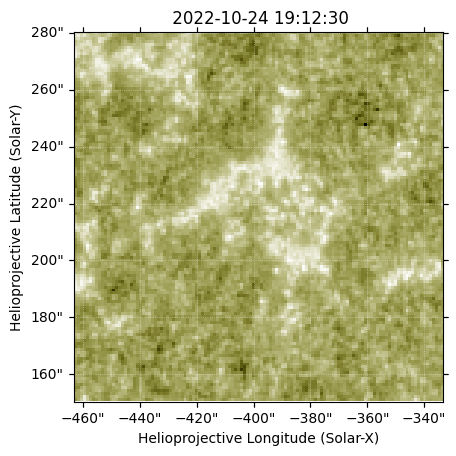

In [49]:
aia_1600_map_to_chase_cutout.plot()

In [50]:
shift_chase_aia, _, _ = phase_cross_correlation(aia_1600_map_to_chase_cutout.data, chase_line_width_cutout_map.data, upsample_factor=10)

In [51]:
shift_chase_aia

array([0. , 2.1])

In [57]:
chase_line_width_cutout_map_shifted = \
    chase_line_width_cutout_map.shift_reference_coord(
    shift_chase_aia[1]*chase_line_width_cutout_map.scale.axis1*u.pix,
    shift_chase_aia[0]*chase_line_width_cutout_map.scale.axis2*u.pix)

In [58]:
with propagate_with_solar_surface():
    SunBlinker(chase_line_width_cutout_map_shifted, aia_1600_map, reproject=True)

In [59]:
np.save("../../data/pid_1_123_aux/CHASE/chase_line_width_npy/chase_line_width_shifted.npy", chase_line_width_cube_shifted)

In [61]:
chase_line_width_cutout_map_shifted.save("../../data/pid_1_123_aux/CHASE/chase_line_width_npy/chase_line_width_wcs_shifted.fits")